# Imports

In [299]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pf
import sys
import os
import h5py
from scipy import constants
from numpy import unravel_index
from scipy.optimize import curve_fit
from h5Manager import ExpViewer

def read_RID(rid, exp_name="ClockRamseyPhase2D"):
    with h5py.File(f'Data/0000{rid}-{exp_name}_exp.h5', 'r') as f:
        x = f['datasets']['detection.images'][:]
    return x

# decaying sine
def sineFit(x, A, phi, y0):
    return (A*np.sin(x+phi)+y0)

def batman(x, n, P0, C):
    return n/np.sqrt(1-((P0-x)/(C/2))**2)

def gausFit(x, A, s):
    return (A*np.exp(-x**2/(2*s**2)))

# Rabi oscillation processing

## 689 Pi Readout 0

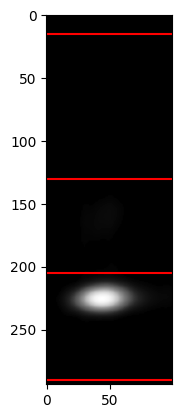

In [395]:
# extract and process images

direc = "C:/Users/ggpan/OneDrive - Stanford/Research/manuscripts/DFSequentialPaper/ThreePhotonSimulations/Data/"
RID = 75653

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

ims = ims[:,20:375, 50:150]
threshold = 8
ims = np.where(ims > threshold, ims, 0)

bins = (15, 130,205,290)
for val in bins:
    plt.axhline(val, color='red')
plt.imshow(1-ims[10],cmap='Greys')  # check that processed image looks good
plt.show()

In [396]:
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[1]:bins[3],:]) for i in range(len(ims))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[1]:bins[3],:]) for i in range(len(ims))]

nrepeats=1
npoints=len(exp.x)*nrepeats
p = np.linspace(0,2*np.pi,int(npoints/nrepeats))

x1avg = np.mean(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x1err= np.std(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x2avg = np.mean(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)
x2err= np.std(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)

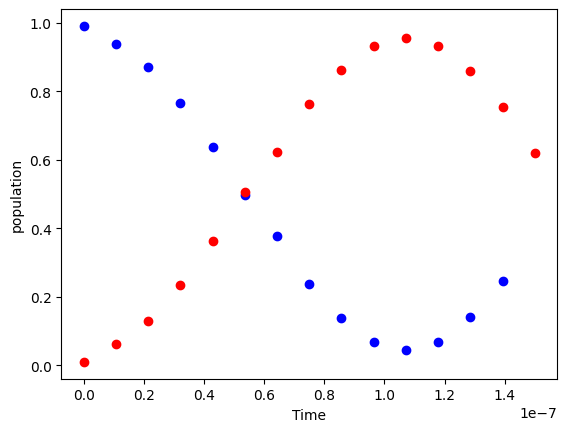

In [397]:
plt.errorbar(exp.x[0:-1],x1avg[0:-1], yerr=x1err[0:-1], fmt='o',color='blue', label='1S0')
plt.errorbar(exp.x,x2avg, yerr=x2err, fmt='o',color='red', label='3P1')
plt.xlabel('Time')
plt.ylabel('population')
plt.show()

g1 = x1avg[0:-4]
g1err = x1err[0:-4]
e1 = x2avg[0:-4]
e1err = x2err[0:-4]
c1 = np.zeros(len(g1))
c1err = np.zeros(len(g1))
par1 = np.zeros(len(g1))
par1err = np.zeros(len(g1))
times1 = exp.x[0:-4]*1e6

## Raman processing

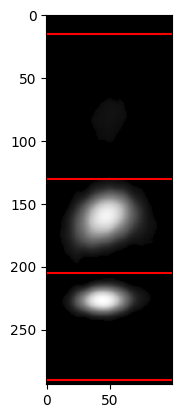

In [398]:
# extract and process images

direc = "C:/Users/ggpan/OneDrive - Stanford/Research/manuscripts/DFSequentialPaper/ThreePhotonSimulations/Data/"
RID = 75659

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

ims = ims[:,20:375, 50:150]
threshold = 8
ims = np.where(ims > threshold, ims, 0)

bins = (15, 130,205,290)
for val in bins:
    plt.axhline(val, color='red')
plt.imshow(1-ims[5],cmap='Greys')  # check that processed image looks good
plt.show()


In [399]:
x0 = [np.sum(ims[i,bins[0]:bins[1],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]

nrepeats=1
npoints=len(exp.x)*nrepeats
p = np.linspace(0,2*np.pi,int(npoints/nrepeats))

x0avg = np.mean(np.reshape(x0,[int(npoints/nrepeats),nrepeats]),axis=1)
x0err= np.std(np.reshape(x0,[int(npoints/nrepeats),nrepeats]),axis=1)
x1avg = np.mean(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x1err= np.std(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x2avg = np.mean(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)
x2err= np.std(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)



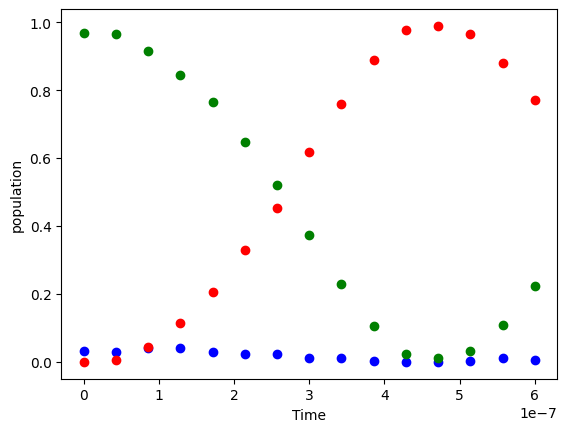

In [400]:
plt.errorbar(exp.x,x0avg, yerr=x0err, fmt='o',color='blue', label='1S0')
plt.errorbar(exp.x,x1avg, yerr=x1err, fmt='o',color='green', label='3P2')
plt.errorbar(exp.x,x2avg, yerr=x2err, fmt='o',color='red', label='3P0')
plt.xlabel('Time')
plt.ylabel('population')
plt.show()


g2 = x0avg
g2err = x0err
c2 = x2avg
c2err = x2err
e2 = x1avg
e2err = x1err

times2 = times1[-1]+0.025+exp.x*1e6

## Composite pi pulse

In [401]:
timesFull=np.append(times1,times2)
cFull = np.append(c1,c2)
gFull = np.append(g1,g2)
eFull = np.append(e1,e2)

cerrFull = np.append(c1err,c2err)
gerrFull = np.append(g1err,g2err)
eerrFull = np.append(e1err,e2err)

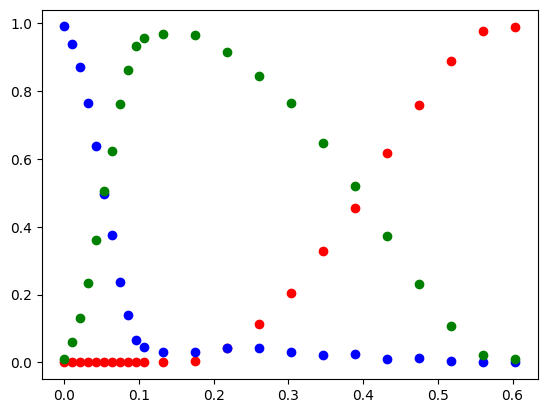

In [402]:

plt.scatter(timesFull[0:-3],cFull[0:-3], color='red')
plt.scatter(timesFull[0:-3],gFull[0:-3], color='blue')
plt.scatter(timesFull[0:-3],eFull[0:-3], color='green')
plt.show()

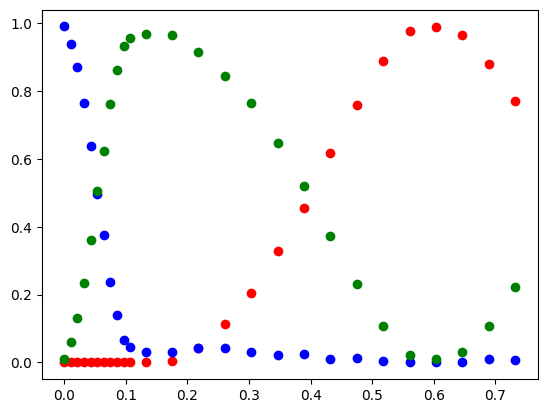

In [403]:
plt.errorbar(timesFull,cFull,yerr=cerrFull, color='red',fmt='o')
plt.errorbar(timesFull,gFull, yerr=gerrFull,color='blue',fmt='o')
plt.errorbar(timesFull,eFull, yerr=eerrFull,color='green',fmt='o')
plt.show()

In [404]:
np.exp(-1.5/21)

0.9310627797040227

In [405]:
cFull[21]-eFull[21]

0.9540616104963535

In [406]:
print(cFull[21])
print(eFull[21])
print(gFull[21])

0.9770308052481768
0.02296919475182322
0.0


In [407]:
pidata=[timesFull[0:-3],gFull[0:-3],eFull[0:-3],cFull[0:-3]]
np.savetxt("seq_pi_040226.csv", pidata, delimiter=",")

# 689 Pi/2 readout 0

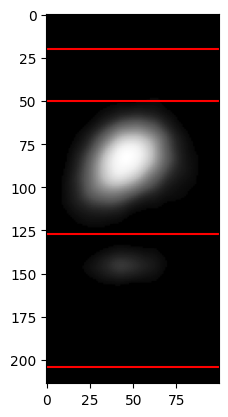

In [378]:
# extract and process images

direc = "C:/Users/ggpan/OneDrive - Stanford/Research/manuscripts/DFSequentialPaper/ThreePhotonSimulations/Data/"
RID = 75654

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

ims = ims[:,100:375, 50:150]
threshold = 8
ims = np.where(ims > threshold, ims, 0)

bins = (20, 50, 127,127+127-50)
for val in bins:
    plt.axhline(val, color='red')
plt.imshow(1-ims[2],cmap='Greys')  # check that processed image looks good
plt.show()

In [379]:
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[1]:bins[3],:]) for i in range(len(ims))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[1]:bins[3],:]) for i in range(len(ims))]

nrepeats=1
npoints=len(exp.x)*nrepeats
p = np.linspace(0,2*np.pi,int(npoints/nrepeats))

x1avg = np.mean(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x1err= np.std(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x2avg = np.mean(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)
x2err= np.std(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)

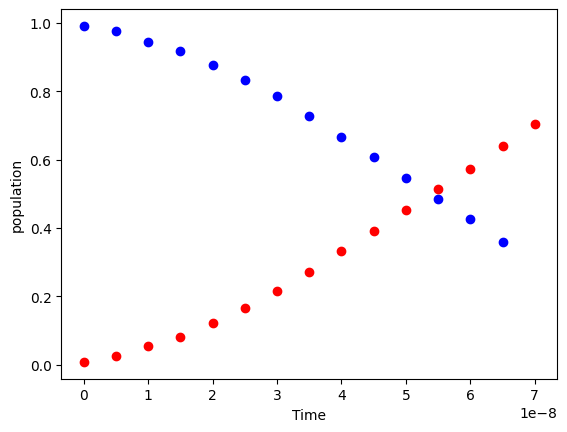

In [380]:
plt.errorbar(exp.x[0:-1],x1avg[0:-1], yerr=x1err[0:-1], fmt='o',color='blue', label='1S0')
plt.errorbar(exp.x,x2avg, yerr=x2err, fmt='o',color='red', label='3P1')
plt.xlabel('Time')
plt.ylabel('population')
plt.show()

g1 = x1avg[0:-3]
g1err = x1err[0:-3]
e1 = x2avg[0:-3]
e1err = x2err[0:-3]
c1 = np.zeros(len(g1))
c1err = np.zeros(len(g1))
par1 = np.zeros(len(g1))
par1err = np.zeros(len(g1))
times1 = exp.x[0:-3]*1e6

# Ramsey transfer

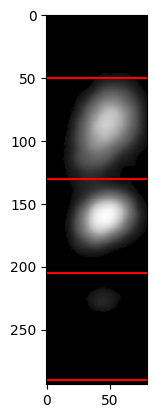

In [390]:
# extract and process images

direc = "C:/Users/ggpan/OneDrive - Stanford/Research/manuscripts/DFSequentialPaper/ThreePhotonSimulations/Data/"
RID = 75655

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

ims = ims[:,20:375, 50:130]
ims = np.where(ims > threshold, ims, 0)

bins = (50, 130,205,290)
for val in bins:
    plt.axhline(val, color='red')
plt.imshow(1-ims[2],cmap='Greys')  # check that processed image looks good
plt.show()


In [391]:
x0 = [np.sum(ims[i,bins[0]:bins[1],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]

nrepeats=1
npoints=len(exp.x)*nrepeats
p = np.linspace(0,2*np.pi,int(npoints/nrepeats))

x0avg = np.mean(np.reshape(x0,[int(npoints/nrepeats),nrepeats]),axis=1)
x0err= np.std(np.reshape(x0,[int(npoints/nrepeats),nrepeats]),axis=1)
x1avg = np.mean(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x1err= np.std(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x2avg = np.mean(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)
x2err= np.std(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)



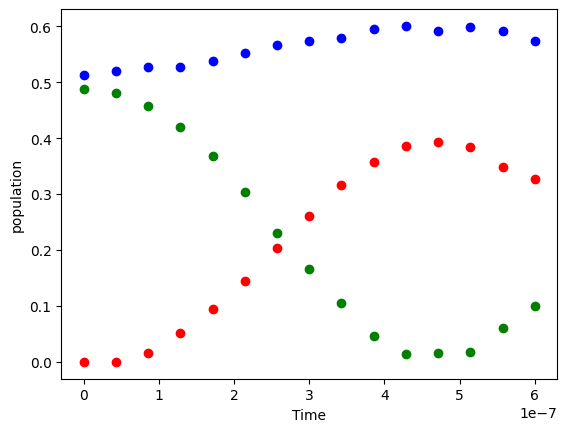

In [392]:
plt.errorbar(exp.x,x0avg, yerr=x0err, fmt='o',color='blue', label='1S0')
plt.errorbar(exp.x,x1avg, yerr=x1err, fmt='o',color='green', label='3P2')
plt.errorbar(exp.x,x2avg, yerr=x2err, fmt='o',color='red', label='3P0')
plt.xlabel('Time')
plt.ylabel('population')
plt.show()


g2 = x0avg
g2err = x0err
c2 = x2avg
c2err = x2err
e2 = x1avg
e2err = x1err

times2 = times1[-1]+exp.x*1e6

# Composite Pi/2

In [393]:
timesFull=np.append(times1,times2)
cFull = np.append(c1,c2)
gFull = np.append(g1,g2)
eFull = np.append(e1,e2)

cerrFull = np.append(c1err,c2err)
gerrFull = np.append(g1err,g2err)
eerrFull = np.append(e1err,e2err)

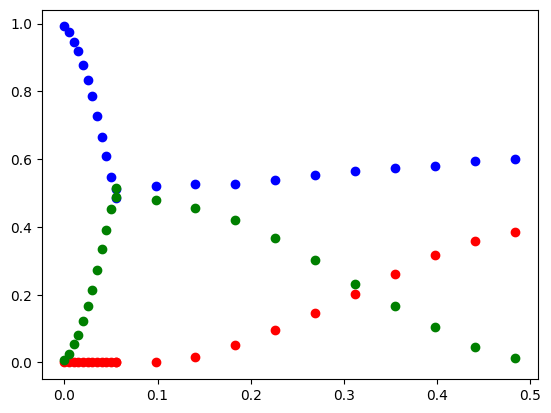

In [394]:
plt.scatter(timesFull[0:-4],cFull[0:-4], color='red')
plt.scatter(timesFull[0:-4],gFull[0:-4], color='blue')
plt.scatter(timesFull[0:-4],eFull[0:-4], color='green')
plt.show()

In [294]:
cFull[-5]

0.4441633182313849

In [295]:
pi2data=[timesFull[0:-4],gFull[0:-4],eFull[0:-4],cFull[0:-4]]
np.savetxt("seq_pi2.csv", pi2data, delimiter=",")